# Pipeline de Regresión Logística para Predicción de Diabetes

**Dataset**: Diabetes Prediction Dataset (Kaggle)

**Objetivo**: Predecir si un paciente tiene diabetes (`diabetes = 1`) basado en 8 características demográficas y clínicas.

**Estrategia**:
1. Variables categóricas → Weight of Evidence (WOE) encoding
2. Variables numéricas → Optimal Binning con transformación WOE
3. Modelo → Regresión Logística con `class_weight='balanced'`
4. Selección de features → Backward Elimination evaluado con el pipeline completo
5. Interpretabilidad → Mappings WOE + train transformado

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (recall_score, roc_auc_score, average_precision_score,
                             f1_score, confusion_matrix)
import utils_pipeline_dhm as up

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


---
## 1. Carga y limpieza de datos

Filtramos:
- `bmi < 65`: outliers biomecánicamente inviables
- `gender != 'Other'`: categoría residual sin masa crítica para WOE

Normalizamos `smoking_history`: `'not current'` y `'ever'` se colapsan en `'former'` para reducir cardinalidad.

In [2]:
data = pd.read_csv('../data/diabetes_prediction_dataset.csv', sep=',')
print(f'Filas en bruto: {data.shape[0]}')

data = data[data['bmi'] < 65]
data = data[data['gender'] != 'Other']
print(f'Filas tras filtros: {data.shape[0]}')

smoking_mapping = {
    'No Info': 'No Info', 'never': 'never', 'former': 'former',
    'current': 'current', 'not current': 'former', 'ever': 'former'
}

X = data.drop(columns=['diabetes'])
y = data['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'\nDistribucion de target (train):\n{y_train.value_counts(normalize=True).to_string()}')

Filas en bruto: 100000
Filas tras filtros: 99935
Train: 79948  |  Test: 19987

Distribucion de target (train):
diabetes
0    0.915095
1    0.084905


---
## 2. Configuración del pipeline por columna

Usamos un `column_config` que especifica explícitamente qué transformación aplicar a cada columna:

| Columna | Transformación | Parámetros |
|--------|---------------|------------|
| `gender` | WOE | — |
| `smoking_history` | WOE | — |
| `hypertension` | WOE | — |
| `heart_disease` | WOE| — |
| `age` | Binning | 8 bins |
| `bmi` | Binning | 8 bins |
| `HbA1c_level` | Binning | 5 bins |
| `blood_glucose_level` | Binning | 4 bins |

`binary_cols` solo se usa para `TypeCaster` (convierte int → str antes de WOE).

In [3]:
binary_cols = ['hypertension', 'heart_disease']

column_config = {
    'gender':               {'transform': 'woe'},
    'smoking_history':      {'transform': 'woe'},
    'hypertension':         {'transform': 'woe'},
    'heart_disease':        {'transform': 'woe'},
    'age':                  {'transform': 'binning', 'max_bins': 8},
    'bmi':                  {'transform': 'binning', 'max_bins': 8},
    'HbA1c_level':         {'transform': 'binning', 'max_bins': 5},
    'blood_glucose_level':  {'transform': 'binning', 'max_bins': 4},
}
all_features = list(column_config.keys())
print(f'{len(all_features)} features configuradas: {all_features}')

8 features configuradas: ['gender', 'smoking_history', 'hypertension', 'heart_disease', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


---
## 3. Construcción del pipeline

**Estructura**:
1. `TypeCaster` — convierte `hypertension` y `heart_disease` de int (0/1) a string
2. `ColumnMapper` — normaliza `smoking_history` según el mapping definido
3. `ColumnConfigPreprocessor` — aplica WOE o binning según `column_config`
4. `LogisticRegression` — modelo final con `class_weight='balanced'`

In [4]:
pipe = Pipeline([
    ('type_cast', up.TypeCaster(columns=binary_cols, dtype=str)),
    ('smoke_map', up.ColumnMapper(column='smoking_history', mapping=smoking_mapping)),
    ('preprocessor', up.ColumnConfigPreprocessor(column_config)),
    ('model', LogisticRegression(class_weight='balanced', random_state=42))
])

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('type_cast', ...), ('smoke_map', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['hypertension', 'heart_disease']"
,dtype,<class 'str'>
,column,'smoking_history'
,mapping,"{'No Info': 'No Info', 'current': 'current', 'ever': 'former', 'former': 'former', ...}"
,column_config,"{'HbA1c_level': {'max_bins': 5, 'transform': 'binning'}, 'age': {'max_bins': 8, 'transform': 'binning'}, 'blood_glucose_level': {'max_bins': 4, 'transform': 'binning'}, 'bmi': {'max_bins': 8, 'transform': 'binning'}, ...}"
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0


---
## 4. Optimización de hiperparámetros

- **Parámetro**: `model__C` (inverso de regularización L2)
- **Grid**: {0.001, 0.01, 0.1, 1.0}
- **CV**: 5-fold estratificado
- **Refit**: PR-AUC (métrica relevante para clases desbalanceadas)
- **Tracking**: ROC-AUC como métrica secundaria

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'}
param_grid = {'model__C': [0.001, 0.01, 0.1, 1.0]}

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring=scoring, refit='pr_auc', n_jobs=-1)
grid.fit(X_train, y_train)
print('GridSearchCV completado.')

GridSearchCV completado.


In [6]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results = cv_results[['param_model__C', 'mean_test_roc_auc', 'mean_test_pr_auc',
                         'std_test_roc_auc', 'std_test_pr_auc']]
cv_results.columns = ['C', 'ROC-AUC (media)', 'PR-AUC (media)', 'ROC-AUC (std)', 'PR-AUC (std)']
display(cv_results.style.format({
    'ROC-AUC (media)': '{:.4f}', 'PR-AUC (media)': '{:.4f}',
    'ROC-AUC (std)': '{:.4f}', 'PR-AUC (std)': '{:.4f}'
}))

best_params = grid.best_params_
best_score = grid.best_score_
print(f'\nMejor C = {best_params["model__C"]}')
print(f'PR-AUC media en CV = {best_score:.4f}')

,C,ROC-AUC (media),PR-AUC (media),ROC-AUC (std),PR-AUC (std)
0,0.001000,0.9362,0.6775,0.0024,0.0043
1,0.010000,0.9365,0.6787,0.0023,0.0043
2,0.100000,0.9365,0.6789,0.0023,0.0041
3,1.000000,0.9365,0.6789,0.0023,0.0040



Mejor C = 0.1
PR-AUC media en CV = 0.6789


---
## 5. Evaluación del modelo completo (8 features)

Calculamos el threshold óptimo sobre **train** maximizando F1-score, luego evaluamos en train y test.

In [7]:
best_model = grid.best_estimator_
train_preds = best_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
opt_t = thresholds[np.argmax([f1_score(y_train, (train_preds >= t).astype(int)) for t in thresholds])]
print(f'Threshold optimo (max F1 en train): {opt_t:.3f}\n')

metrics = []
for name, X, y in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    preds = best_model.predict_proba(X)[:, 1]
    metrics.append({
        'Set': name,
        'PR-AUC': average_precision_score(y, preds),
        'ROC-AUC': roc_auc_score(y, preds),
        'Recall': recall_score(y, (preds >= opt_t).astype(int))
    })

display(pd.DataFrame(metrics).style.format({
    'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Recall': '{:.4f}'
}))

Threshold optimo (max F1 en train): 0.840



,Set,PR-AUC,ROC-AUC,Recall
0,Train,0.6818,0.9375,0.6298
1,Test,0.6802,0.9405,0.6370


### Coeficientes del modelo

In [8]:
model = best_model.named_steps['model']
fnames = best_model.named_steps['preprocessor'].get_feature_names_out()
coef_df = pd.DataFrame({
    'feature': fnames,
    'coef': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('coef', ascending=False)

display(coef_df.style.format({'coef': '{:.4f}', 'odds_ratio': '{:.4f}'}))

,feature,coef,odds_ratio
1,smoking_history,-0.3939,0.6744
3,heart_disease,-0.4881,0.6138
2,hypertension,-0.5203,0.5943
5,bmi,-0.7257,0.4840
0,gender,-0.7378,0.4782
4,age,-0.7954,0.4514
7,blood_glucose_level,-0.9799,0.3754
6,HbA1c_level,-1.0020,0.3671


---
## 6. Backward Elimination

**Mecanismo**:
- Partimos de las 8 features completas
- En cada iteración probamos eliminar cada feature candidata
- La candidata que menos perjudique el PR-AUC es eliminada permanentemente
- Repetimos hasta quedar con 1 feature
- Seleccionamos el subset óptimo vía **elbow ratio** (caída abrupta en PR-AUC)

In [9]:
best_C = grid.best_params_['model__C']
remaining = all_features.copy()
backward_results = []
cv_sel = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos el conjunto completo
pr_m, pr_s, roc_m, roc_s = up.evaluate(
    up.build_pipe(remaining, best_C, column_config, binary_cols, smoking_mapping),
    X_train, y_train, cv_sel)
backward_results.append({
    'n_features': 8, 'drop': '(ninguna)',
    'features': ', '.join(sorted(remaining)),
    'pr_auc': f'{pr_m:.4f} \u00b1{pr_s:.4f}',
    'roc_auc': f'{roc_m:.4f} \u00b1{roc_s:.4f}'
})

while len(remaining) > 1:
    best_auc = -1.0
    best_candidate = None

    for candidate in remaining:
        temp = [f for f in remaining if f != candidate]
        pr_m_temp, _, _, _ = up.evaluate(
            up.build_pipe(temp, best_C, column_config, binary_cols, smoking_mapping),
            X_train, y_train, cv_sel)
        if pr_m_temp > best_auc:
            best_auc = pr_m_temp
            best_candidate = candidate

    remaining.remove(best_candidate)
    pr_m, pr_s, roc_m, roc_s = up.evaluate(
        up.build_pipe(remaining, best_C, column_config, binary_cols, smoking_mapping),
        X_train, y_train, cv_sel)
    backward_results.append({
        'n_features': len(remaining),
        'drop': best_candidate,
        'features': ', '.join(sorted(remaining)),
        'pr_auc': f'{pr_m:.4f} \u00b1{pr_s:.4f}',
        'roc_auc': f'{roc_m:.4f} \u00b1{roc_s:.4f}'
    })

be_df = pd.DataFrame(backward_results)
display(be_df.style.hide(axis='index'))
print('')

n_features,drop,features,pr_auc,roc_auc
8,(ninguna),"HbA1c_level, age, blood_glucose_level, bmi, gender, heart_disease, hypertension, smoking_history",0.6789 ±0.0041,0.9365 ±0.0023
7,gender,"HbA1c_level, age, blood_glucose_level, bmi, heart_disease, hypertension, smoking_history",0.6779 ±0.0047,0.9363 ±0.0023
6,smoking_history,"HbA1c_level, age, blood_glucose_level, bmi, heart_disease, hypertension",0.6737 ±0.0056,0.9356 ±0.0023
5,heart_disease,"HbA1c_level, age, blood_glucose_level, bmi, hypertension",0.6677 ±0.0053,0.9343 ±0.0024
4,hypertension,"HbA1c_level, age, blood_glucose_level, bmi",0.6568 ±0.0048,0.9320 ±0.0021
3,bmi,"HbA1c_level, age, blood_glucose_level",0.6101 ±0.0066,0.9243 ±0.0022
2,age,"HbA1c_level, blood_glucose_level",0.4724 ±0.0105,0.8805 ±0.0047
1,blood_glucose_level,HbA1c_level,0.2670 ±0.0059,0.8034 ±0.0045


### Selección del subset óptimo via Elbow Ratio

Buscamos la iteración donde la **pérdida relativa** de PR-AUC es máxima: el punto de inflexión donde eliminar la siguiente feature empieza a degradar significativamente el rendimiento.

In [10]:
be_df['pr_val'] = be_df['pr_auc'].str.extract(r'([\d.]+)').astype(float)
losses = be_df['pr_val'].diff().abs().dropna()
ratios = losses / losses.shift(1)
elbow_idx = ratios.dropna().idxmax()
optimal_n = int(be_df.loc[elbow_idx, 'n_features'] + 1)
selected = be_df[be_df['n_features'] == optimal_n]['features'].iloc[0].split(', ')

# Mostramos las pérdidas relativas para ver el codo visualmente
elbow_df = be_df[['n_features', 'drop', 'pr_auc']].copy()
elbow_df['perdida_pr'] = be_df['pr_val'].diff().abs()
elbow_df['ratio_perdida'] = ratios
display(elbow_df.style.hide(axis='index').format({
    'perdida_pr': '{:.4f}', 'ratio_perdida': '{:.2f}'
}))

print(f'\nSubset optimo: {len(selected)} features')
print(f'Features: {selected}')

n_features,drop,pr_auc,perdida_pr,ratio_perdida
8,(ninguna),0.6789 ±0.0041,nan,nan
7,gender,0.6779 ±0.0047,0.0010,nan
6,smoking_history,0.6737 ±0.0056,0.0042,4.20
5,heart_disease,0.6677 ±0.0053,0.0060,1.43
4,hypertension,0.6568 ±0.0048,0.0109,1.82
3,bmi,0.6101 ±0.0066,0.0467,4.28
2,age,0.4724 ±0.0105,0.1377,2.95
1,blood_glucose_level,0.2670 ±0.0059,0.2054,1.49



Subset optimo: 4 features
Features: ['HbA1c_level', 'age', 'blood_glucose_level', 'bmi']


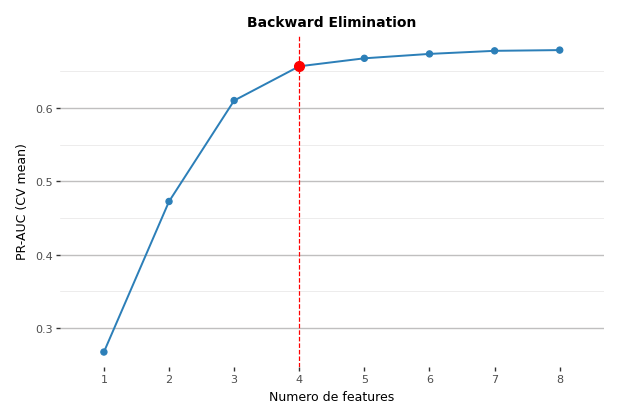

In [11]:
up.plot_elbow(be_df, optimal_n).draw()

---
## 7. Evaluación final con el subset óptimo

Reentrenamos el pipeline completo solo con las features seleccionadas y medimos rendimiento en train y test.

,Set,Threshold,PR-AUC,ROC-AUC,Recall
0,Train,0.820,0.6605,0.9330,0.6323
1,Test,0.850,0.6683,0.9357,0.6223


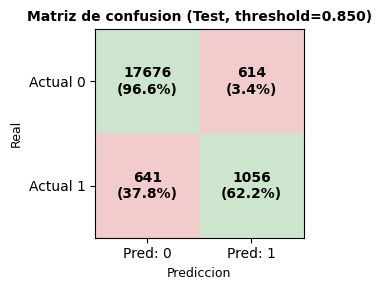

In [12]:
X_train_sel = X_train[selected]
X_test_sel = X_test[selected]

final_pipe = up.build_pipe(selected, best_C, column_config, binary_cols, smoking_mapping)
final_pipe.fit(X_train_sel, y_train)

final_metrics = []
for name, X, y in [('Train', X_train_sel, y_train), ('Test', X_test_sel, y_test)]:
    preds = final_pipe.predict_proba(X)[:, 1]
    opt_t = thresholds[np.argmax([f1_score(y, (preds >= t).astype(int)) for t in thresholds])]
    final_metrics.append({
        'Set': name,
        'Threshold': opt_t,
        'PR-AUC': average_precision_score(y, preds),
        'ROC-AUC': roc_auc_score(y, preds),
        'Recall': recall_score(y, (preds >= opt_t).astype(int))
    })

display(pd.DataFrame(final_metrics).style.format({
    'Threshold': '{:.3f}', 'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}', 'Recall': '{:.4f}'
}))

# Matriz de confusion en Test
preds_test = final_pipe.predict_proba(X_test_sel)[:, 1]
cm_t = thresholds[np.argmax([f1_score(y_test, (preds_test >= t).astype(int)) for t in thresholds])]
cm = confusion_matrix(y_test, (preds_test >= cm_t).astype(int))

up.plot_confusion_matrix(cm, title=f'Matriz de confusion (Test, threshold={cm_t:.3f})')
plt.show()

---
## 8. Interpretabilidad

### WOE Mappings

Cada feature transformada tiene un mapping que muestra:
- Para **WOE**: categoría original → `woe_raw` (WOE calculado) y `woe_model` (lo que ve el modelo, con signo invertido)
- Para **Binning**: bin → `woe_raw` y `IV` (Information Value, poder predictivo de cada bin)

**Interpretación**: `woe_model` positivo = mayor riesgo de diabetes. Un coeficiente negativo en el modelo multiplica a `woe_model`, por lo que contribuciones netas altas (positivas) se dan cuando signos coinciden.

In [13]:
preproc = final_pipe.named_steps['preprocessor']
mappings_df = preproc.get_mappings()
display(mappings_df.style.format({
    'woe_raw': '{:.4f}', 'woe_model': '{:.4f}', 'IV': '{:.4f}'
}).hide(axis='index'))

feature,category_bin,transformation,woe_raw,woe_model,IV
age,"(-inf, 5.50)",binning,4.2006,4.2006,0.2847
age,"[5.50, 13.50)",binning,2.8432,2.8432,0.2032
age,"[13.50, 27.50)",binning,2.1685,2.1685,0.3414
age,"[27.50, 38.50)",binning,1.1257,1.1257,0.1153
age,"[38.50, 46.50)",binning,0.3538,0.3538,0.0122
age,"[46.50, 53.50)",binning,-0.1117,-0.1117,0.0014
age,"[53.50, 62.50)",binning,-0.6375,-0.6375,0.0687
age,"[62.50, inf)",binning,-1.0035,-1.0035,0.3142
age,Special,binning,0.0000,0.0000,0.0000
age,Missing,binning,0.0000,0.0000,0.0000


### Train transformado

Primeras filas del dataset de entrenamiento después de aplicar el pipeline completo (TypeCaster → ColumnMapper → ColumnConfigPreprocessor). Cada columna contiene el valor WOE o binned que el modelo realmente usa.

In [14]:
X_train_tf = final_pipe[:-1].transform(X_train_sel)
display(X_train_tf.head(10).style.format({col: '{:.4f}' for col in X_train_tf.columns}))

,age,bmi,HbA1c_level,blood_glucose_level
15163,0.3538,1.0790,1.8097,1.6126
41142,4.2006,2.3983,1.8097,1.6126
20453,-0.1117,0.2953,0.0946,0.1996
45884,2.1685,0.2953,0.0946,-1.8091
45480,1.1257,0.2953,0.0946,-1.8091
60415,4.2006,2.3983,1.8097,0.1996
97948,1.1257,0.6105,0.1210,1.6126
5067,-1.0035,-0.8869,1.8097,1.6126
51370,2.8432,2.3983,1.8097,0.1996
40539,-1.0035,-0.2535,1.8097,0.1996


---
### Perfil de cada feature

Grafico de barras (frecuencia normalizada) + linea (tasa de diabetes) por categoria/bin, ordenado por proporcion de target=1. Muestra la monotonia de la relacion WOE y la distribucion de cada categoria.

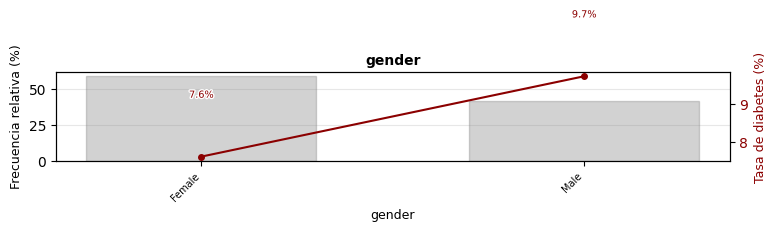

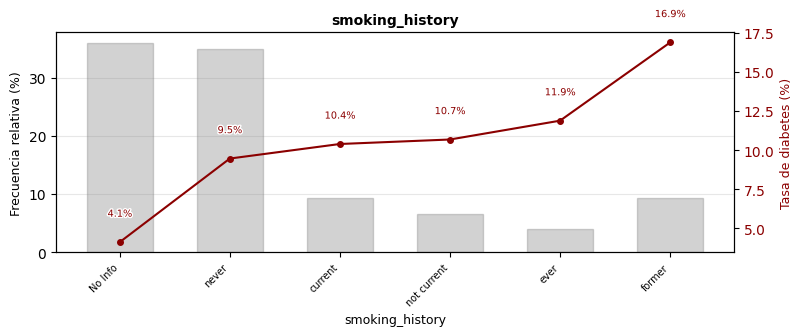

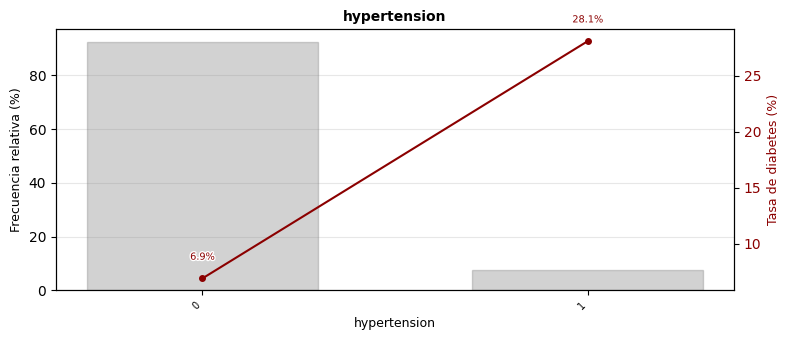

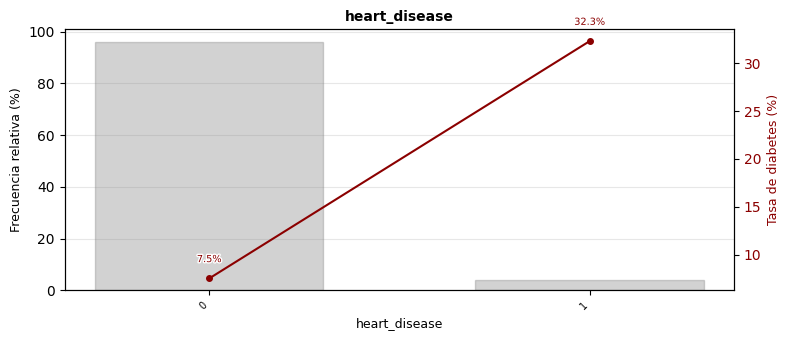

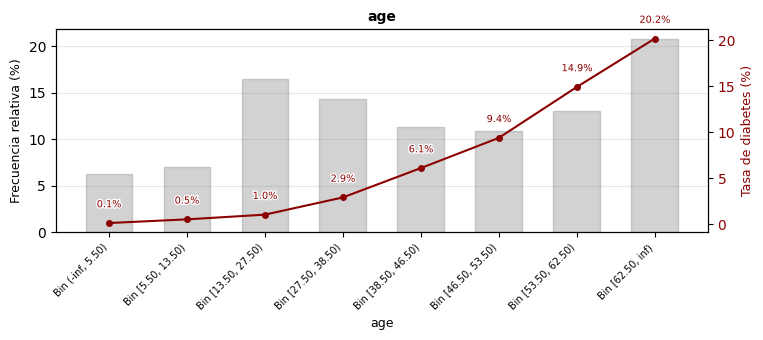

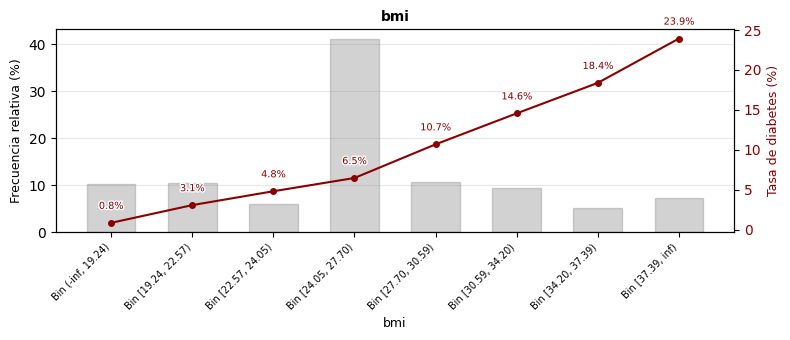

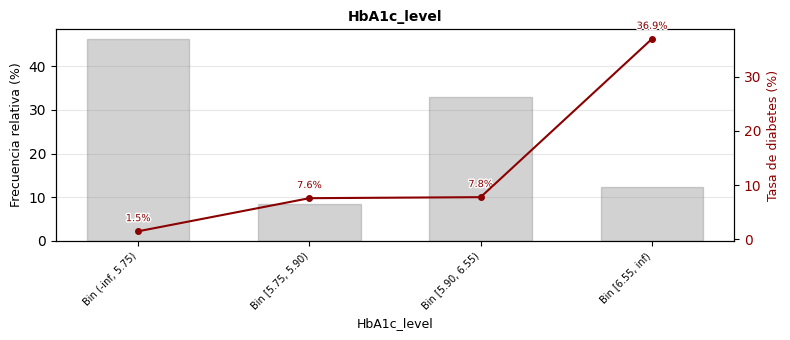

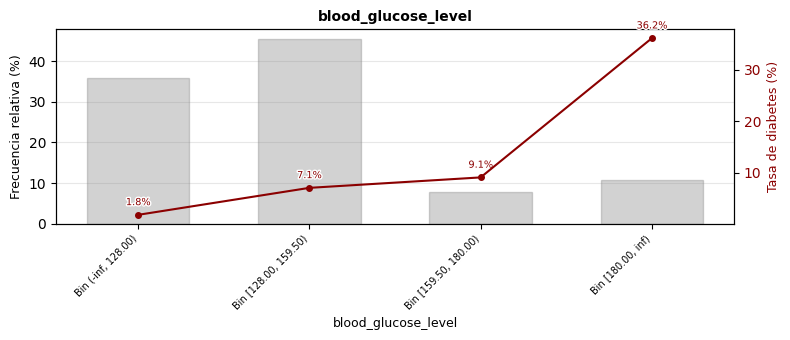

In [15]:
preproc_8feat = best_model.named_steps['preprocessor']

for feat in all_features:
    fig = up.plot_feature_profile(
        feature=feat,
        X_raw=X_train,
        y=y_train,
        column_config=column_config,
        preproc=preproc_8feat,
        fig_size=(8, 3.5)
    )
    plt.show()

---
## Conclusiones

### 1. Hiperparámetros
- Mejor **C = 0.1** (regularización moderada)
- PR-AUC en CV: **~0.679**

### 2. Selección de features
- Backward elimination descartó **gender**, **smoking_history**, **heart_disease** e **hypertension** (todas las WOE categóricas)
- Subset óptimo (elbow ratio): **4 features numéricas**: `age`, `bmi`, `HbA1c_level`, `blood_glucose_level`
- **PR-AUC en Test: ~0.668** (pérdida marginal vs 0.680 con 8 features)

### 3. Interpretación de WOE
- **HbA1c_level** es el predictor más fuerte: IV = 0.84 en el bin superior (>6.55). `woe_model` negativo para valores altos = más riesgo
- **blood_glucose_level**: IV = 0.70 en el bin superior (≥180). Misma dirección: niveles altos incrementan riesgo
- **Age**: IV = 0.34 en el bin más joven (<5.5 años, protección) y 0.31 en el más mayor (≥62.5, riesgo)
- **Bmi**: obesidad (≥37.39) muestra el mayor riesgo relativo con IV = 0.17

### 4. Rendimiento del modelo
- **ROC-AUC ~0.936**: excelente discriminación global
- **Recall ~0.62-0.66**: identificamos ~2 de cada 3 diabéticos reales
- El threshold óptimo (~0.85) es alto debido al desbalance (92% no diabéticos)